# Data Leakage — a step-by-step, runnable notebook

A model reports **95%** in your notebook and **70%** in the real world. That gap is the single most expensive bug in applied machine learning, and its most common cause is **data leakage**: at training time the model saw information it will *not* have at prediction time. The score was never real.

Leakage is invisible in a single number — a great score looks like a great model. The only way to *see* it is to measure the **same problem two ways**: a leaky protocol and an honest one, side by side. This notebook does exactly that, one measurement at a time, for the three leaks you will actually meet:

1. **Preprocessing leakage** — selecting features on the whole dataset before cross-validating. We use pure **noise** with a random label, so the honest answer is *provably* chance (0.50) — and any accuracy above it is leakage, measured. Leaky CV says **0.86**; the `Pipeline` fix says **0.48**.
2. **Target leakage** — a column that is a proxy for the label, on the **real Breast Cancer** dataset. It takes accuracy to **1.00**; drop it and the honest **0.96** returns.
3. **Temporal leakage** — a random split of a time series trains on the future. Shuffled R² **0.97**; a forward `TimeSeriesSplit` says **0.69**.

Everything is the executable companion to the chapter and to `data_leakage.py`; every function used here lives in that module, imported so the notebook and the module can never drift apart. It all runs on CPU in a few seconds, seeded for reproducibility.

## Step 0 — Setup and version banner

Import the real functions from the chapter module (so this notebook uses the *exact same code* the figures and the page use) and print the library versions the results were produced on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from data_leakage import (
    make_noise_data, selection_leak, selection_leak_sweep,
    make_breast_cancer_leak, target_leak,
    make_time_series, temporal_leak,
    CHANCE, CV_FOLDS, LEAK_COL_NAME,
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

print(f'numpy {np.__version__} | scikit-learn {sklearn.__version__}')
print(f'cross-validation folds used throughout: {CV_FOLDS}')

numpy 2.4.6 | scikit-learn 1.9.0
cross-validation folds used throughout: 5


## Step 1 — A dataset where we KNOW the honest answer

To turn leakage into a *measurement* we need a dataset whose honest accuracy we already know. So we build one with **no signal at all**: 200 rows of 5,000 pure-Gaussian-noise features and a **random** 0/1 label, drawn without ever looking at the features. The best any honest model can possibly do out-of-sample is **chance, 0.50**. Anything above that is not skill — it is information leaking.

In [2]:
noise = make_noise_data()
print(f'X: {noise.x.shape[0]} rows x {noise.x.shape[1]} pure-noise features')
print(f'y: balanced random label, class counts = {np.bincount(noise.y)}')
# a sanity check: no single feature is meaningfully correlated with the label
corrs = np.abs([np.corrcoef(noise.x[:, j], noise.y)[0, 1] for j in range(200)])
print(f'largest |corr(feature, label)| among the first 200 columns: {corrs.max():.3f}  (pure chance)')
print(f'=> the honest generalization accuracy is provably {CHANCE:.2f}. Remember that number.')

X: 200 rows x 5000 pure-noise features
y: balanced random label, class counts = [100 100]
largest |corr(feature, label)| among the first 200 columns: 0.175  (pure chance)
=> the honest generalization accuracy is provably 0.50. Remember that number.


## Step 2 — The leaky protocol: select features on ALL the data

Here is the mistake, and it looks completely reasonable. We pick the 50 features most correlated with the label using **`SelectKBest` on the whole dataset**, and *then* cross-validate a classifier on those columns. The bug: the selector looked at every row — including the rows each fold will later be scored on. It has already peeked at the answer key.

In [3]:
clf = LogisticRegression(max_iter=1000, random_state=42)
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

# LEAKY: select on all of X, y first, then cross-validate on the pre-selected columns
x_selected = SelectKBest(f_classif, k=50).fit_transform(noise.x, noise.y)
leaky_cv = np.mean(cross_val_score(clf, x_selected, noise.y, cv=cv))
print(f'LEAKY cross-validated accuracy: {leaky_cv:.3f}')
print(f'...on data with NO signal, whose honest accuracy is {CHANCE:.2f}.')
print('That 0.86 is pure fiction — the selection saw the test folds.')

LEAKY cross-validated accuracy: 0.860
...on data with NO signal, whose honest accuracy is 0.50.
That 0.86 is pure fiction — the selection saw the test folds.


## Step 3 — The fix: put selection INSIDE a Pipeline

The cure is structural. Wrap the *same* `SelectKBest` and classifier in a `Pipeline` and hand the whole thing to `cross_val_score`. Now scikit-learn re-fits the selector on **each training fold only**, so the columns it picks are correlated with the label on the training rows but not on the held-out fold. The score falls straight back to chance — the truth.

In [4]:
# HONEST: selection lives inside the pipeline, re-fit on each training fold only
pipe = Pipeline([('select', SelectKBest(f_classif, k=50)), ('clf', clf)])
honest_cv = np.mean(cross_val_score(pipe, noise.x, noise.y, cv=cv))
print(f'LEAKY  CV accuracy (select on all data) : {leaky_cv:.3f}')
print(f'HONEST CV accuracy (select in Pipeline)  : {honest_cv:.3f}  (~chance)')
print(f'measured inflation gap                   : {leaky_cv - honest_cv:+.3f}')
assert leaky_cv > honest_cv + 0.15, 'the leak must materially inflate the score'
assert abs(honest_cv - CHANCE) < 0.1, 'the honest score must sit near chance'
print('\nSame data, same model, same k — only WHERE the selector was fit changed the answer.')

LEAKY  CV accuracy (select on all data) : 0.860
HONEST CV accuracy (select in Pipeline)  : 0.480  (~chance)
measured inflation gap                   : +0.380

Same data, same model, same k — only WHERE the selector was fit changed the answer.


## Step 4 — Confirm it with an untouched hold-out

Cross-validation can feel abstract, so let's confirm the honest number a second, independent way: fit the honest pipeline on a training split and score it **once** on a test set it has never seen. If it also lands near chance, we can trust that the honest ~0.48 — not the leaky 0.86 — is the real generalization accuracy. The `selection_leak` helper runs all three at once.

In [5]:
sel = selection_leak(noise)
print(f'leaky CV        : {sel.leaky_cv:.3f}   <- inflated fiction')
print(f'honest CV       : {sel.honest_cv:.3f}   <- the truth (~chance)')
print(f'honest hold-out : {sel.honest_holdout:.3f}   <- an untouched test set agrees')
print(f'\ninflation gap  : {sel.gap:+.3f}  ({sel.gap*100:.0f} points of pure leakage)')

leaky CV        : 0.860   <- inflated fiction
honest CV       : 0.480   <- the truth (~chance)
honest hold-out : 0.533   <- an untouched test set agrees

inflation gap  : +0.380  (38 points of pure leakage)


## Step 5 — The more you let it peek, the bigger the lie

Leakage is not all-or-nothing — it scales with *how much* information you let in. Sweep the number of cherry-picked features `k`: the **leaky** curve climbs toward 1.0 (more noise columns to fit the test folds with), while the **honest** curve never leaves chance for any `k`. The widening gap is the leak, drawn as a dial you control.

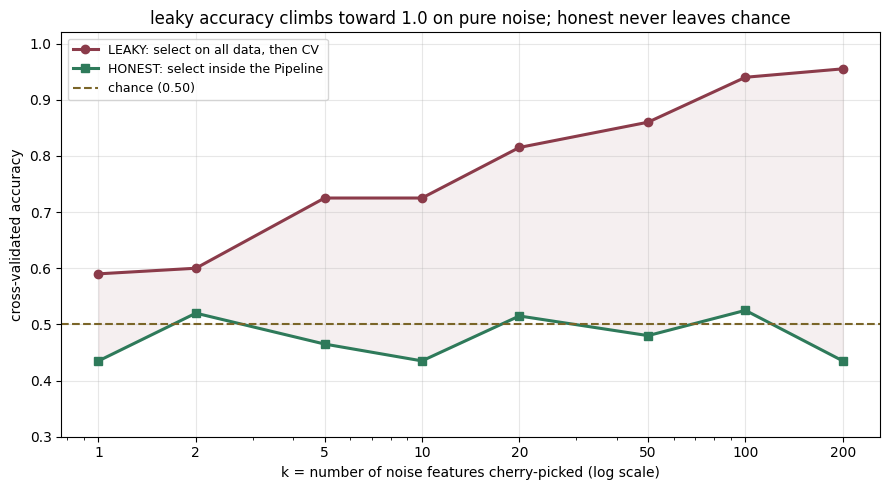

k=   1  leaky=0.590  honest=0.435  gap=+0.155
k=   2  leaky=0.600  honest=0.520  gap=+0.080
k=   5  leaky=0.725  honest=0.465  gap=+0.260
k=  10  leaky=0.725  honest=0.435  gap=+0.290
k=  20  leaky=0.815  honest=0.515  gap=+0.300
k=  50  leaky=0.860  honest=0.480  gap=+0.380
k= 100  leaky=0.940  honest=0.525  gap=+0.415
k= 200  leaky=0.955  honest=0.435  gap=+0.520


In [6]:
ks, leaky, honest = selection_leak_sweep(noise)
plt.figure(figsize=(9, 5))
plt.plot(ks, leaky, 'o-', color='#8B3B4A', lw=2.2, label='LEAKY: select on all data, then CV')
plt.plot(ks, honest, 's-', color='#2E7A5A', lw=2.2, label='HONEST: select inside the Pipeline')
plt.axhline(CHANCE, color='#7A6528', ls='--', lw=1.5, label=f'chance ({CHANCE:.2f})')
plt.fill_between(ks, honest, leaky, color='#8B3B4A', alpha=0.08)
plt.xscale('log')
plt.xticks(ks, [str(k) for k in ks])
plt.xlabel('k = number of noise features cherry-picked (log scale)')
plt.ylabel('cross-validated accuracy')
plt.ylim(0.3, 1.02)
plt.title('leaky accuracy climbs toward 1.0 on pure noise; honest never leaves chance')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
for k, leaky_k, honest_k in zip(ks, leaky, honest):
    print(f'k={k:>4}  leaky={leaky_k:.3f}  honest={honest_k:.3f}  gap={leaky_k-honest_k:+.3f}')

## Step 6 — Target leakage on REAL data: a proxy for the label

The second leak needs no synthetic noise — it happens on real datasets constantly. We load the real **Breast Cancer Wisconsin** data (569 patients, 30 genuine measurements) and append one realistic **leaky** column: a *confirmatory marker recorded after the biopsy*. In the database it looks like just another feature; in truth it is a near-copy of the diagnosis — and it will not exist when we predict on a new patient.

In [7]:
bundle = make_breast_cancer_leak()
print(f'real features: {bundle.x_clean.shape[1]}   (+1 injected leak = {bundle.x_leaky.shape[1]} total)')
leak = bundle.x_leaky[:, bundle.leak_col]
corr = np.abs(np.corrcoef(leak, bundle.y)[0, 1])
print(f'the leaked column: {LEAK_COL_NAME!r}')
print(f'|corr(leaked column, label)| = {corr:.3f}   (a feature that is basically the answer)')

real features: 30   (+1 injected leak = 31 total)
the leaked column: 'confirmatory_marker (LEAK)'
|corr(leaked column, label)| = 0.972   (a feature that is basically the answer)


## Step 7 — Measure it: with the leak, without it, and the leak alone

Cross-validate a random forest three ways: with the leaked column, on the 30 real features only, and on the **leaked column alone**. That last one is the smoking gun — if a *single* column predicts the diagnosis almost perfectly, it is not a feature, it is the label in disguise. The cure is not a clever transform; it is *deleting information you won't have at prediction time*.

In [8]:
tgt = target_leak(bundle)
print(f'accuracy WITH the leaked column       : {tgt.acc_with_leak:.3f}   <- inflated')
print(f'accuracy on the 30 REAL features only : {tgt.acc_without_leak:.3f}   <- honest')
print(f'accuracy using ONLY the leaked column : {tgt.acc_leak_only:.3f}   <- it IS the answer')
print(f'\ninflation gap: {tgt.gap:+.3f}. The 1.00 is a mirage — one post-diagnosis column carries it.')
assert tgt.acc_with_leak > tgt.acc_without_leak
assert tgt.acc_leak_only > 0.9

accuracy WITH the leaked column       : 1.000   <- inflated
accuracy on the 30 REAL features only : 0.963   <- honest
accuracy using ONLY the leaked column : 1.000   <- it IS the answer

inflation gap: +0.037. The 1.00 is a mirage — one post-diagnosis column carries it.


## Step 8 — See why: the leaked column separates the classes on its own

Plot the leaked column split by diagnosis. Two cleanly separated humps mean the column all but *is* the label — exactly the fingerprint of target leakage. A legitimate feature overlaps heavily across classes; a leak looks like this.

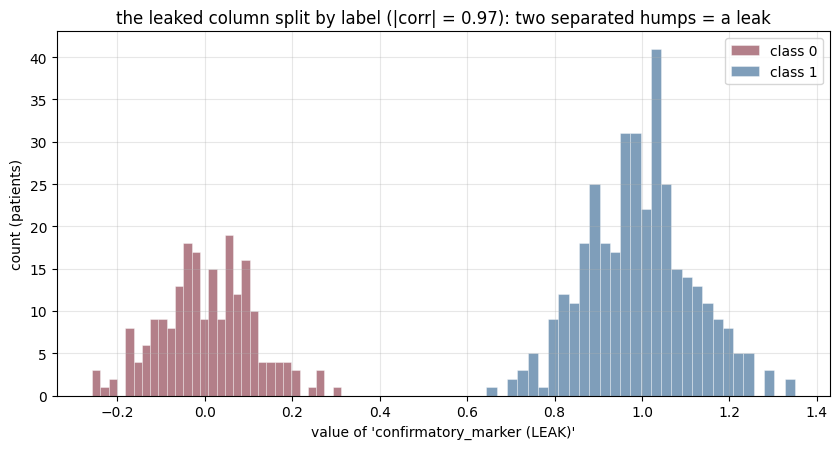

In [9]:
plt.figure(figsize=(8.5, 4.6))
for cls, colour, name in [(0, '#8B3B4A', 'class 0'), (1, '#3A6B96', 'class 1')]:
    plt.hist(leak[bundle.y == cls], bins=30, color=colour, alpha=0.65, edgecolor='white', lw=0.4, label=name)
plt.xlabel(f'value of {LEAK_COL_NAME!r}')
plt.ylabel('count (patients)')
plt.title(f'the leaked column split by label (|corr| = {corr:.2f}): two separated humps = a leak')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9 — Temporal leakage: build a realistic time series

The third leak is about *time*. We simulate two years of daily observations with the three ingredients real series have: an upward **trend**, a **weekly** cycle, and **autocorrelated** noise (today looks like yesterday). All three make adjacent days similar — which is exactly what a careless split will exploit. The task: predict each day from its previous 7 days (lag features).

series: 730 daily observations
supervised rows: 723 x 7 lag features (y[t-1..t-7]) -> y[t]


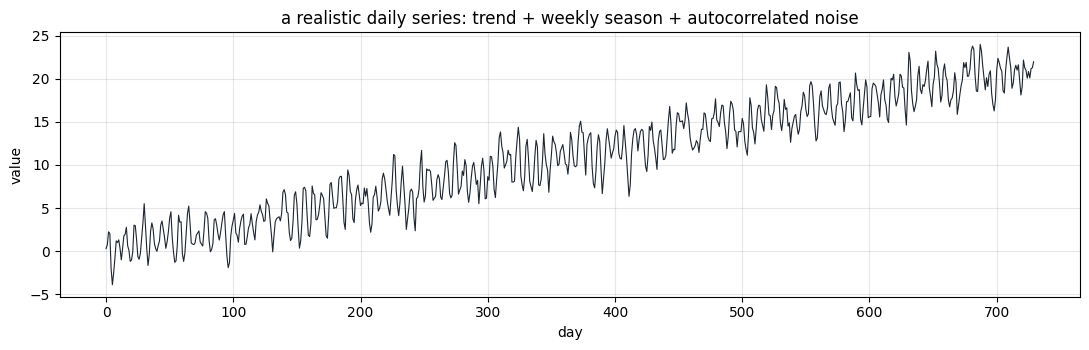

In [10]:
ts = make_time_series()
print(f'series: {ts.series.shape[0]} daily observations')
print(f'supervised rows: {ts.x.shape[0]} x {ts.x.shape[1]} lag features (y[t-1..t-7]) -> y[t]')
plt.figure(figsize=(11, 3.6))
plt.plot(ts.series, color='#1C2530', lw=0.8)
plt.xlabel('day')
plt.ylabel('value')
plt.title('a realistic daily series: trend + weekly season + autocorrelated noise')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10 — Random split vs forward TimeSeriesSplit

Same model (ridge on the lag features), same data — only the **splitting** differs. A shuffled K-fold puts *future* days into the training set for a given test day; since neighbours are similar, the model practically reads the answer off them, and R² looks great. `TimeSeriesSplit` always trains on an earlier window and tests on a later one — the real forecasting task — and reports the honest, lower R².

In [11]:
tmp = temporal_leak(ts)
print(f'shuffled K-fold R^2 (trains on the FUTURE)   : {tmp.shuffled_r2:.3f}   <- inflated')
print(f'forward TimeSeriesSplit R^2 (past -> future) : {tmp.forward_r2:.3f}   <- honest')
print(f'\ninflation gap: {tmp.gap:+.3f} R^2. Shuffling time-ordered data lets you see tomorrow.')
assert tmp.shuffled_r2 > tmp.forward_r2

shuffled K-fold R^2 (trains on the FUTURE)   : 0.968   <- inflated
forward TimeSeriesSplit R^2 (past -> future) : 0.692   <- honest

inflation gap: +0.276 R^2. Shuffling time-ordered data lets you see tomorrow.


## Step 11 — Why: a shuffled split scatters the future into training

The picture makes it obvious. A **forward** split cuts the timeline once: train on the past (left), predict the future (right). A **shuffled** split sprinkles test days (red) *between* training days (blue) — so for almost every test day, both its neighbours are in the training set, and the model can interpolate the answer it is supposed to forecast.

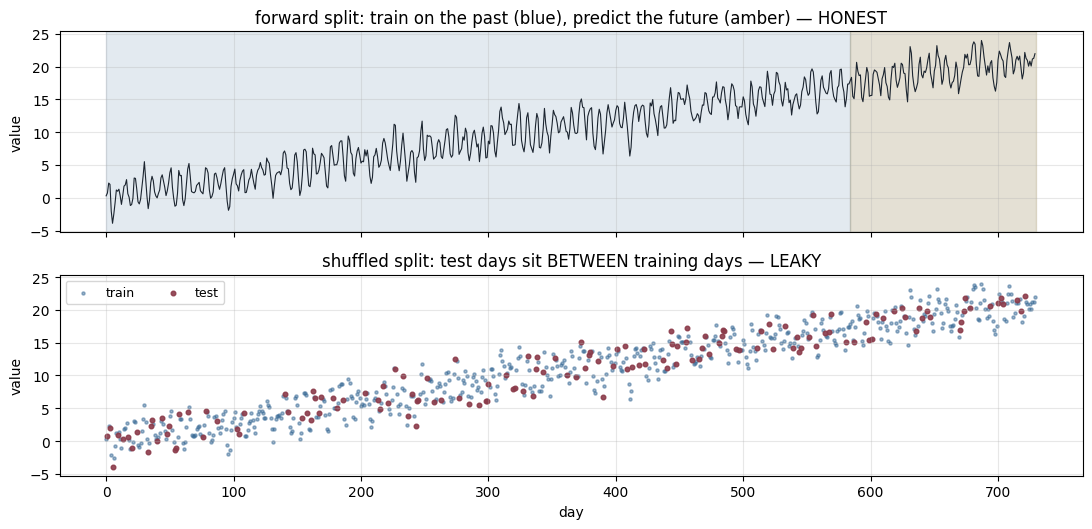

In [12]:
n = ts.series.shape[0]
cut = int(n * 0.8)
rng = np.random.default_rng(0)
test_idx = rng.choice(n, size=int(n * 0.2), replace=False)
mask = np.zeros(n, dtype=bool)
mask[test_idx] = True
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True)
a1.plot(ts.series, color='#1C2530', lw=0.8)
a1.axvspan(0, cut, color='#3A6B96', alpha=0.14)
a1.axvspan(cut, n, color='#7A6528', alpha=0.20)
a1.set_title('forward split: train on the past (blue), predict the future (amber) — HONEST')
a1.set_ylabel('value')
a2.scatter(np.arange(n)[~mask], ts.series[~mask], s=5, color='#3A6B96', alpha=0.5, label='train')
a2.scatter(np.arange(n)[mask], ts.series[mask], s=11, color='#8B3B4A', alpha=0.9, label='test')
a2.set_title('shuffled split: test days sit BETWEEN training days — LEAKY')
a2.set_ylabel('value')
a2.set_xlabel('day')
a2.legend(ncol=2, fontsize=9)
a1.grid(alpha=0.3)
a2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 12 — The one habit that prevents all three

Three different leaks, one discipline: **every data-dependent step must be fit using only the training portion of each split — and the split must respect time.** In scikit-learn that is two rules:

1. Put **every** transform (scaling, imputation, feature selection, encoding, target statistics) inside a `Pipeline`, and cross-validate the *pipeline* — never fit a transform on all the data first.
2. For time-ordered data, split by **time** (`TimeSeriesSplit`), never shuffle.

And drop any feature that won't exist at prediction time. Below is the honest pattern in full — the template you should reach for every time.

In [13]:
from sklearn.preprocessing import StandardScaler

# the honest, leak-proof template: transforms fit per-fold, inside cross-validation
honest_pipeline = Pipeline([
    ('scale', StandardScaler()),               # fit on each training fold only
    ('select', SelectKBest(f_classif, k=50)),  # fit on each training fold only
    ('clf', LogisticRegression(max_iter=1000, random_state=42)),
])
score = np.mean(cross_val_score(honest_pipeline, noise.x, noise.y, cv=cv))
print(f'honest pipeline on the noise data: {score:.3f}  (~chance {CHANCE:.2f}, as it must be)')
print('Every transform saw only training rows. No number here is a lie.')

honest pipeline on the noise data: 0.480  (~chance 0.50, as it must be)


Every transform saw only training rows. No number here is a lie.


## Recap

Three leaks, each measured as the gap between a leaky protocol and the honest truth:

| Step | Leak | Leaky score | Honest score | The fix |
|---|---|---|---|---|
| 1–5 | **Preprocessing** — select features on all data | **0.86** | **0.48** (≈ chance) | selection inside a `Pipeline`, re-fit per fold |
| 6–8 | **Target** — a proxy-of-the-label column (real data) | **1.00** | **0.96** | drop features unavailable at prediction time |
| 9–11 | **Temporal** — a shuffled split of a time series | **0.97** R² | **0.69** R² | split by time (`TimeSeriesSplit`) |
| 12 | — | — | — | fit every transform on train only; respect time |

**Leakage is about the protocol, not the model.** A score you cannot reproduce out-of-sample is the red flag — and the only way to catch a leak is to build the honest protocol and watch the inflated number collapse. Fit every data-dependent step inside the cross-validation loop, split time-ordered data by time, and never train on information the future will not have.